Saving bulbs.png to bulbs (1).png
Grayscale Image:


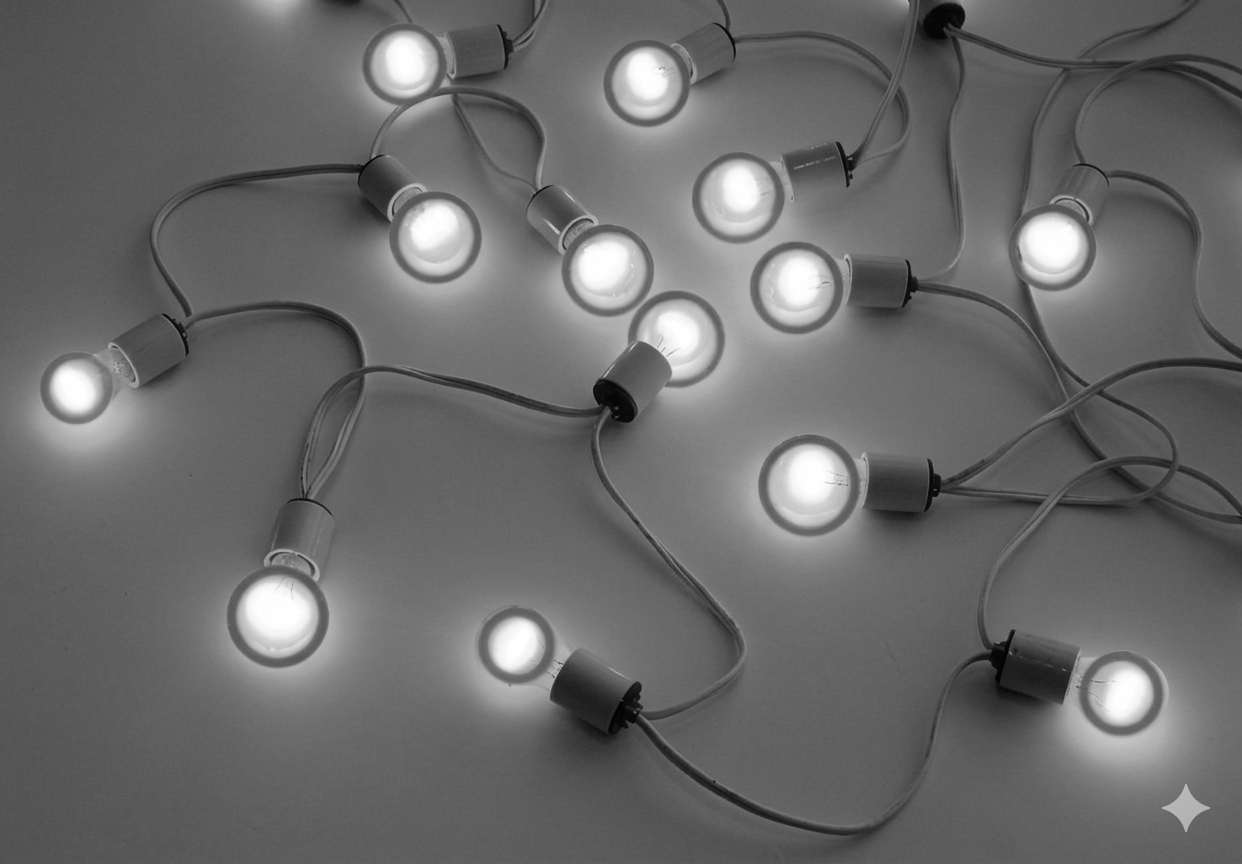

Blurred Image:


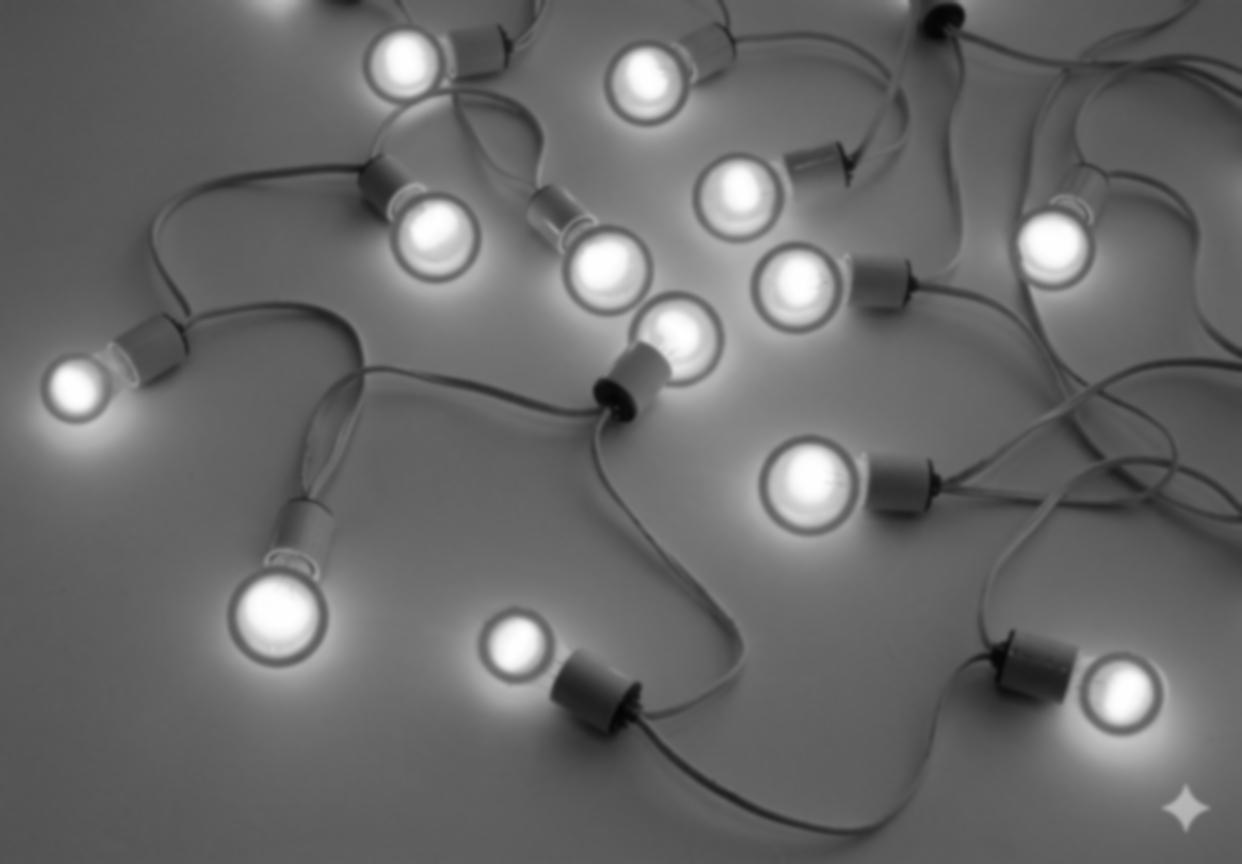

Thresholded Image:


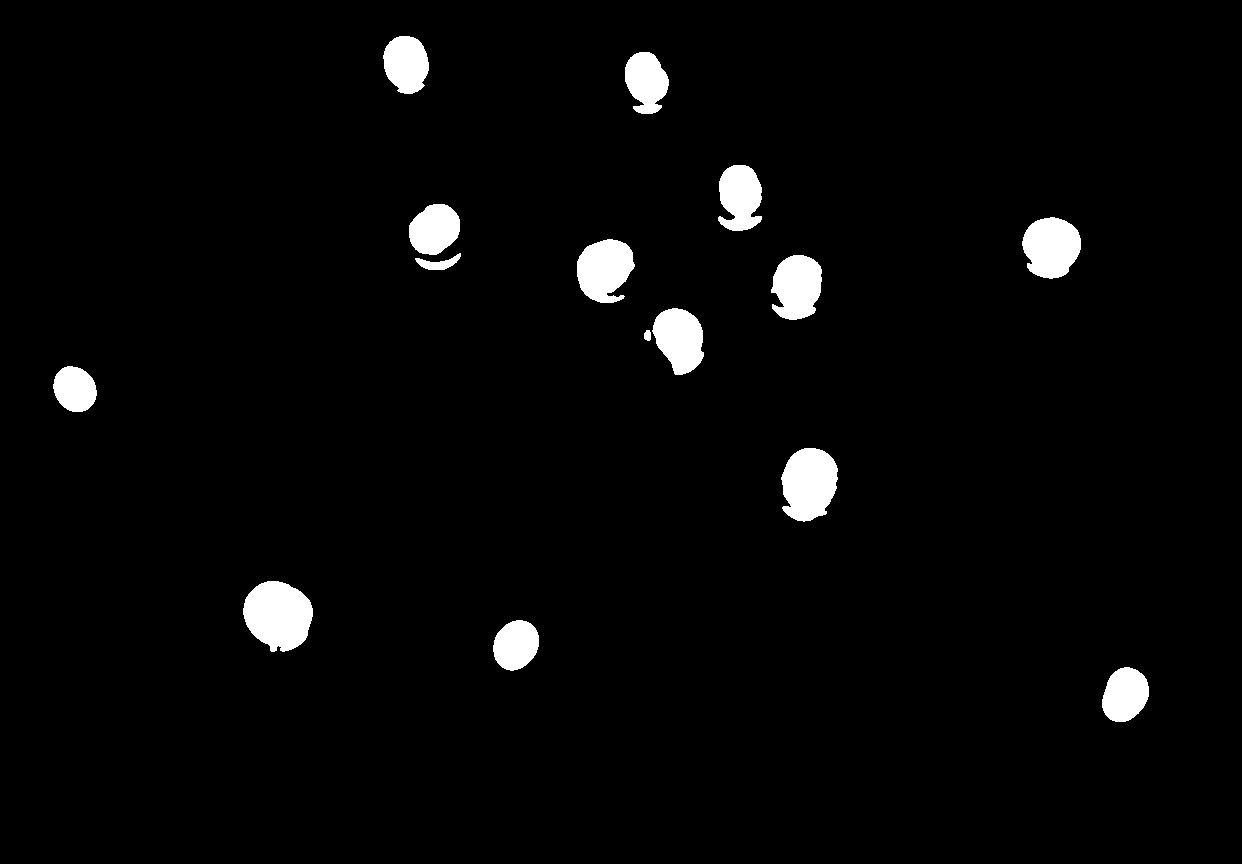

After Noise Removal:


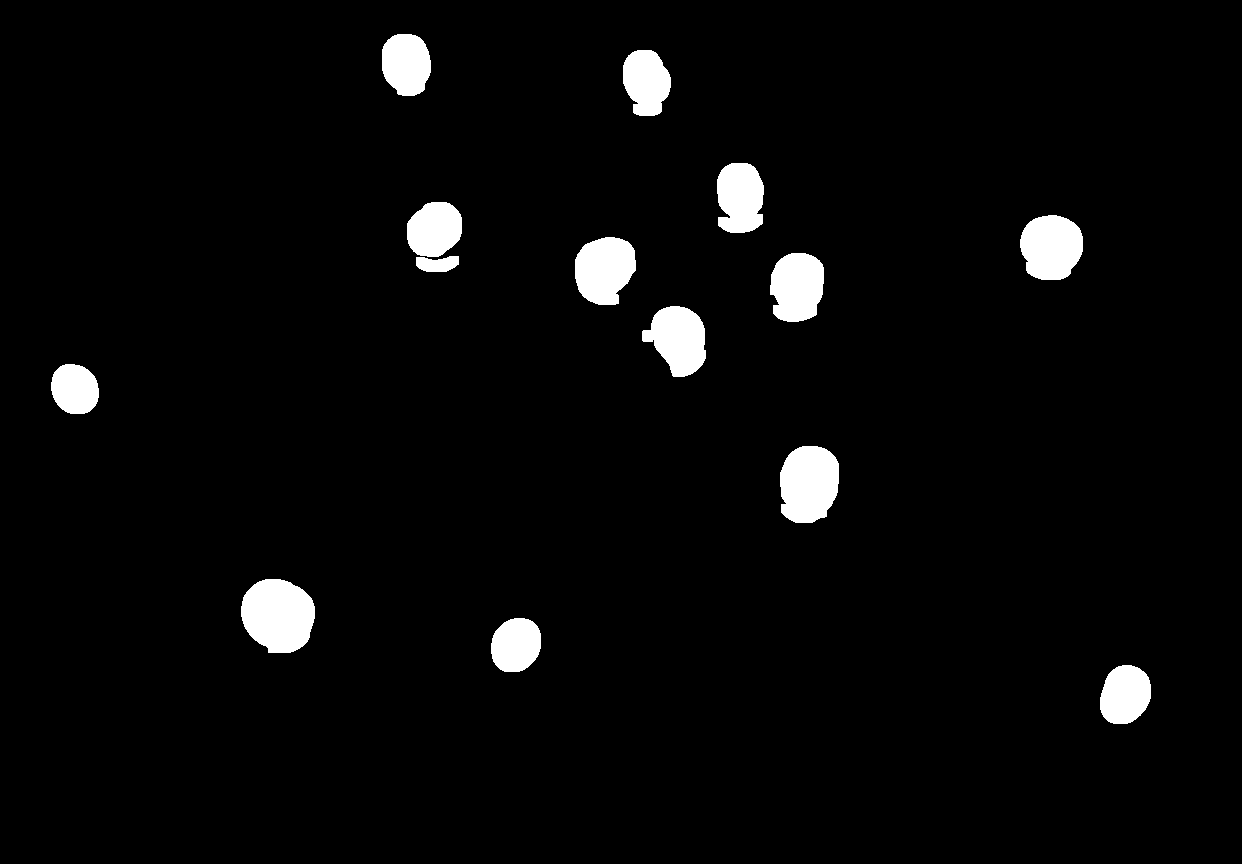

Filtered Bright Regions:


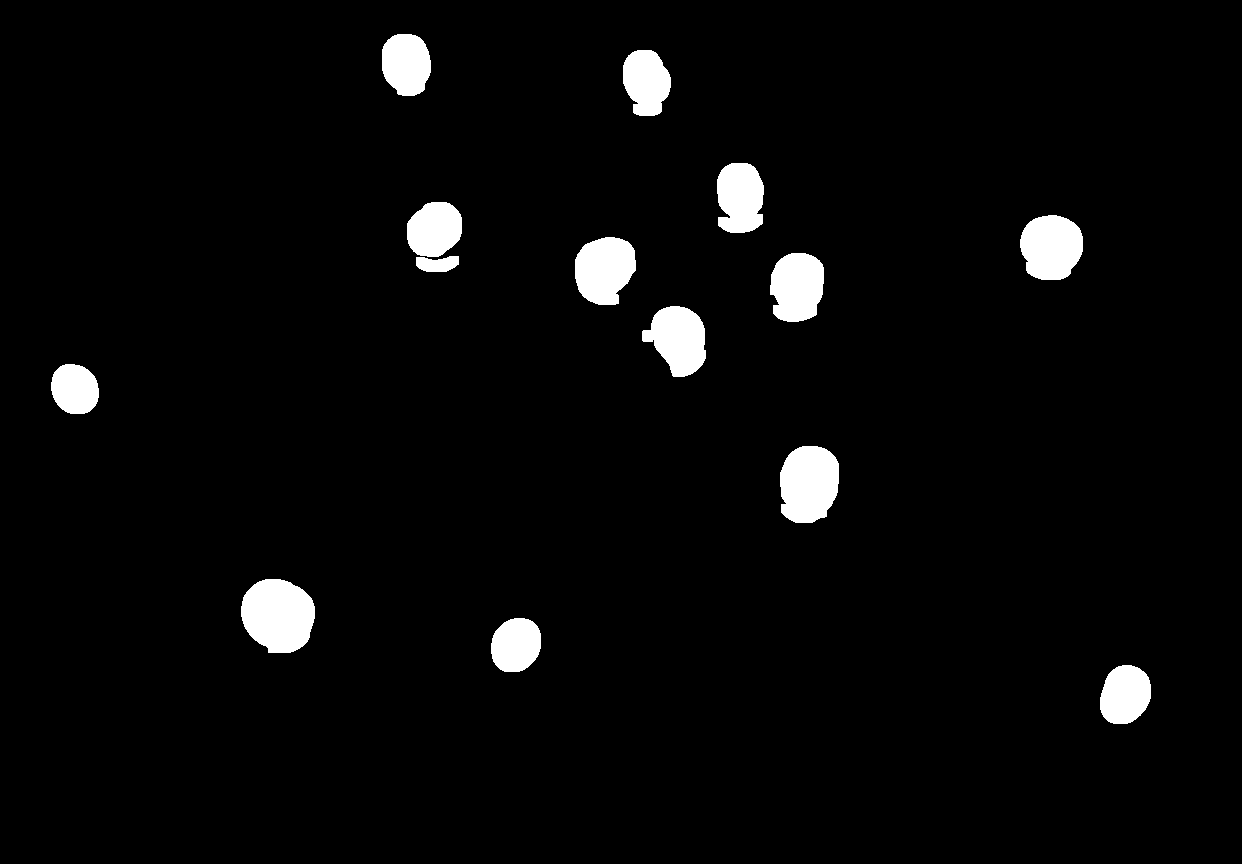

Final Output (Detected Bright Spots):


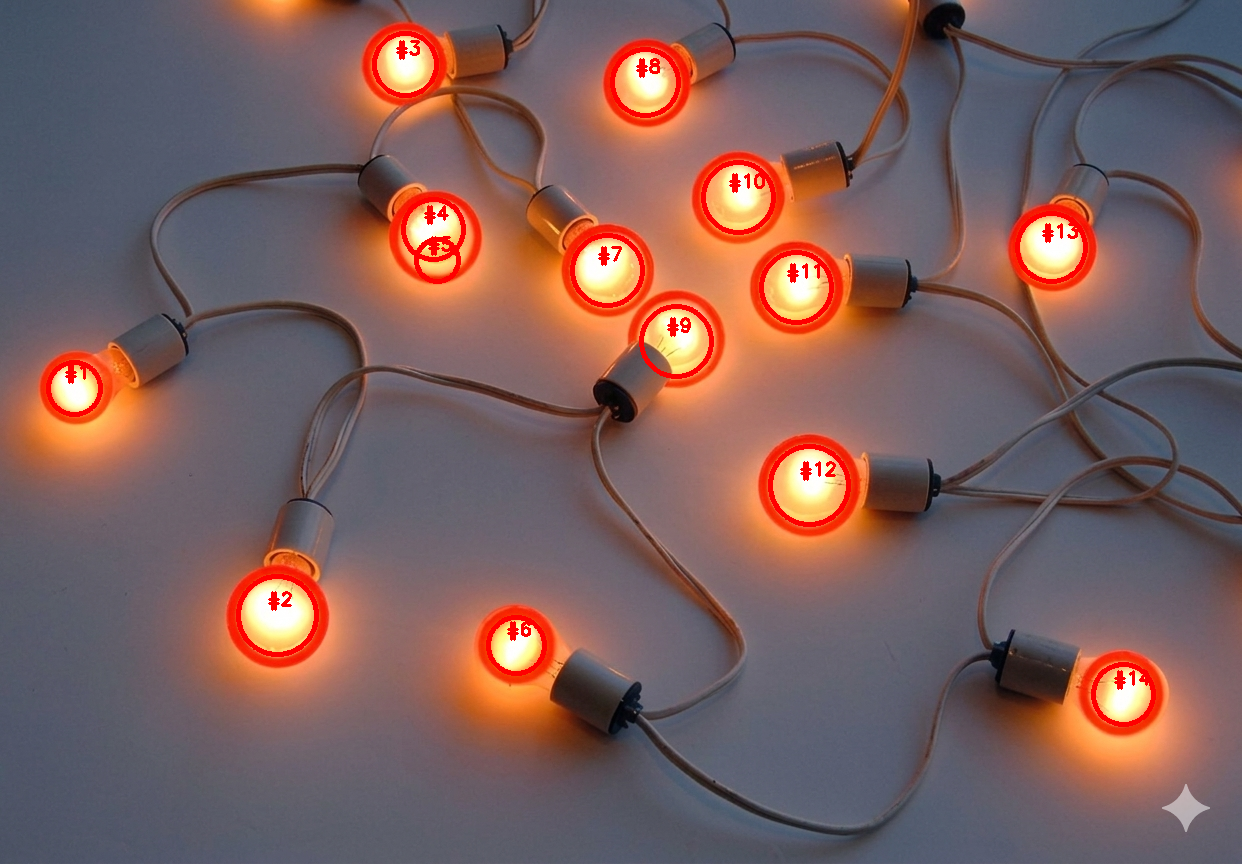

In [2]:
# ================================
# 🔷 INSTALL REQUIRED LIBRARIES
# ================================
!pip install imutils scikit-image

# ================================
# 🔷 IMPORT LIBRARIES
# ================================
import cv2                      # OpenCV for image processing
import numpy as np              # Numerical operations
import imutils                  # Helper utilities
from imutils import contours    # For sorting contours
from skimage import measure     # Connected component analysis
from google.colab.patches import cv2_imshow  # Display images in Colab
from google.colab import files  # For uploading images

# ================================
# 🔷 UPLOAD IMAGE
# ================================
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# ================================
# 🔷 LOAD & PREPROCESS IMAGE
# ================================
# Load image
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray, (11, 11), 0)

# Show intermediate results
print("Grayscale Image:")
cv2_imshow(gray)

print("Blurred Image:")
cv2_imshow(blurred)

# ================================
# 🔷 THRESHOLDING (BRIGHT REGIONS)
# ================================
# Convert bright regions to white, rest to black
thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)[1]

print("Thresholded Image:")
cv2_imshow(thresh)

# ================================
# 🔷 MORPHOLOGICAL OPERATIONS
# ================================
# Remove small noise (erosion)
thresh = cv2.erode(thresh, None, iterations=2)

# Restore object size (dilation)
thresh = cv2.dilate(thresh, None, iterations=4)

print("After Noise Removal:")
cv2_imshow(thresh)

# ================================
# 🔷 CONNECTED COMPONENT ANALYSIS
# ================================
# Label connected regions (blobs)
labels = measure.label(thresh, connectivity=2, background=0)

# Create mask to store only large blobs
mask = np.zeros(thresh.shape, dtype="uint8")

# Loop through all detected components
for label in np.unique(labels):

    # Ignore background
    if label == 0:
        continue

    # Create mask for current component
    labelMask = np.zeros(thresh.shape, dtype="uint8")
    labelMask[labels == label] = 255

    # Count pixels in component
    numPixels = cv2.countNonZero(labelMask)

    # Keep only large components
    if numPixels > 300:
        mask = cv2.add(mask, labelMask)

print("Filtered Bright Regions:")
cv2_imshow(mask)

# ================================
# 🔷 FIND CONTOURS & DRAW OUTPUT
# ================================
# Detect contours
cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)

# Handle OpenCV version differences
cnts = imutils.grab_contours(cnts)

# Sort contours from left to right
cnts = contours.sort_contours(cnts)[0]

# Loop through contours and draw results
for (i, c) in enumerate(cnts):

    # Compute minimum enclosing circle
    ((cX, cY), radius) = cv2.minEnclosingCircle(c)

    # Draw circle around bright spot
    cv2.circle(image, (int(cX), int(cY)), int(radius),
               (0, 0, 255), 3)

    # Label each detected spot
    cv2.putText(image, f"#{i+1}",
                (int(cX) - 10, int(cY) - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (0, 0, 255), 2)

# ================================
# 🔷 FINAL OUTPUT
# ================================
print("Final Output (Detected Bright Spots):")
cv2_imshow(image)